In [ ]:
from google.colab import files

uploaded = files.upload()

Saving titanic.csv to titanic (3).csv


First 5 Rows:
   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 

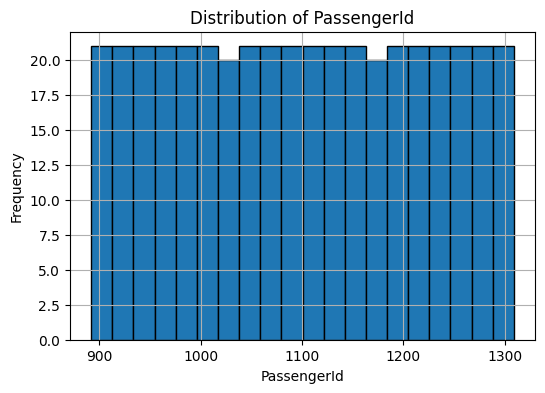

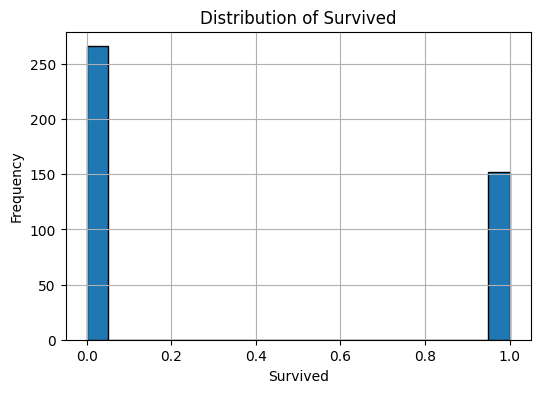

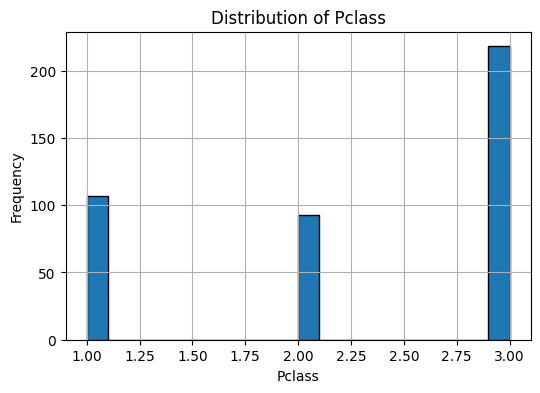

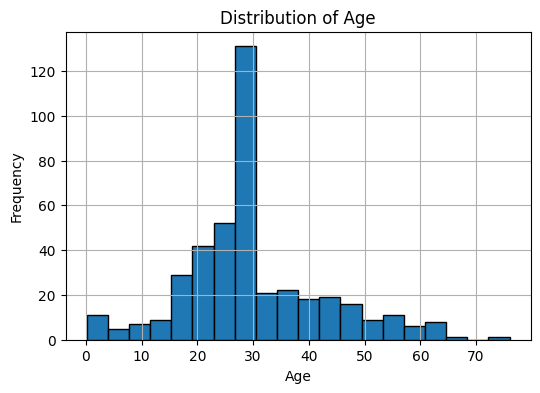

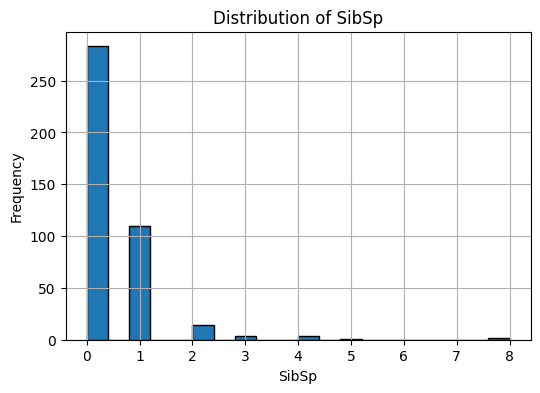

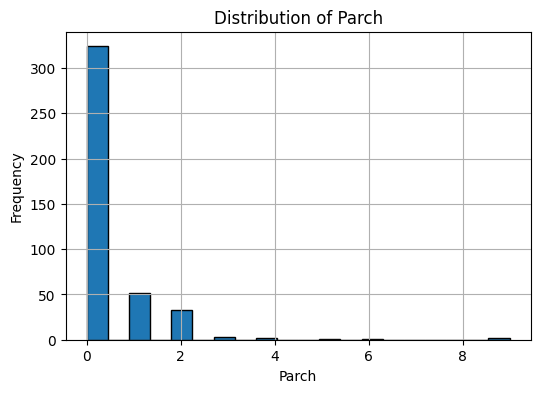

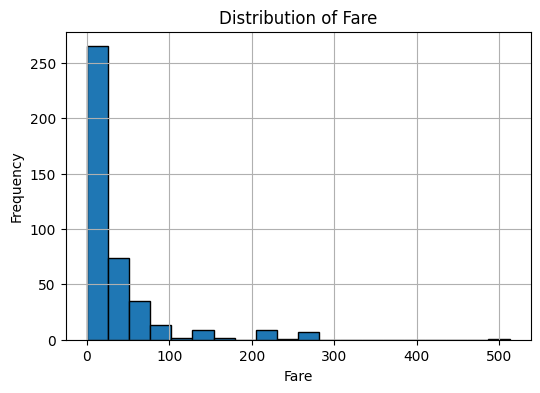


Correlation Matrix:
             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.023245 -0.026751 -0.030874  0.003818  0.043080   
Survived       -0.023245  1.000000 -0.108615 -0.000011  0.099943  0.159120   
Pclass         -0.026751 -0.108615  1.000000 -0.440782  0.001087  0.018721   
Age            -0.030874 -0.000011 -0.440782  1.000000 -0.079535 -0.045073   
SibSp           0.003818  0.099943  0.001087 -0.079535  1.000000  0.306895   
Parch           0.043080  0.159120  0.018721 -0.045073  0.306895  1.000000   
Fare            0.008209  0.191382 -0.576619  0.326800  0.171488  0.230001   

                 Fare  
PassengerId  0.008209  
Survived     0.191382  
Pclass      -0.576619  
Age          0.326800  
SibSp        0.171488  
Parch        0.230001  
Fare         1.000000  


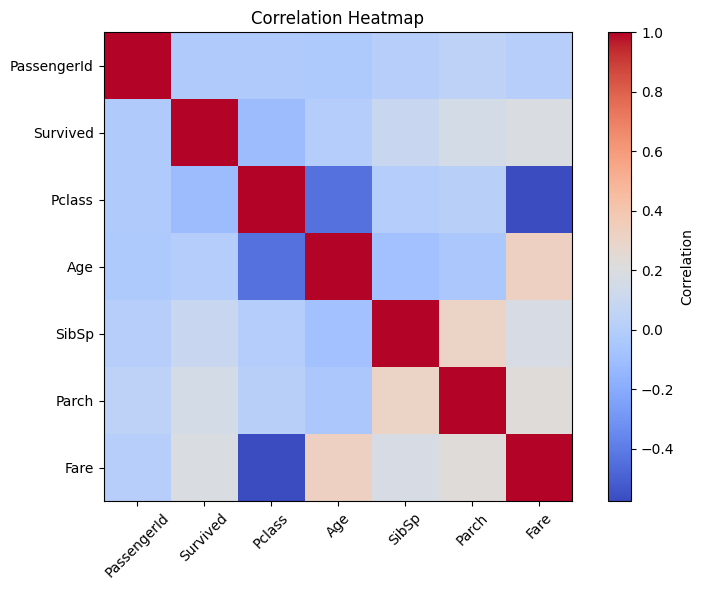

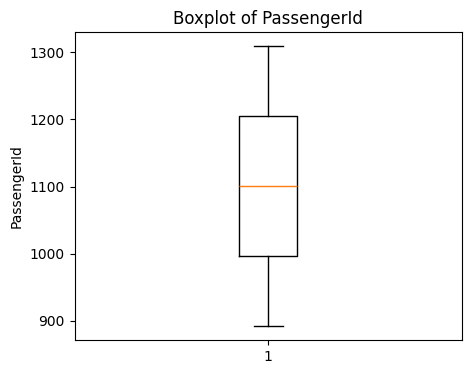

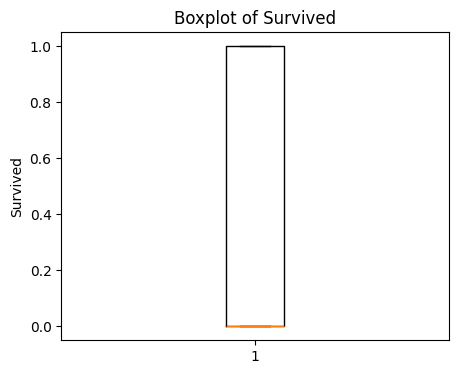

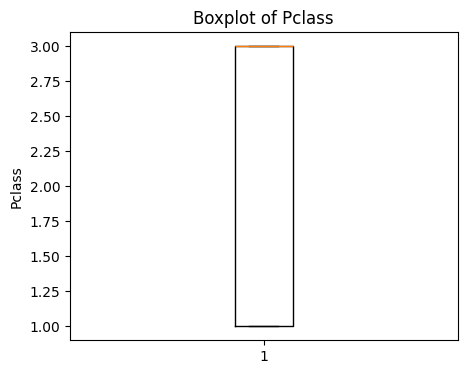

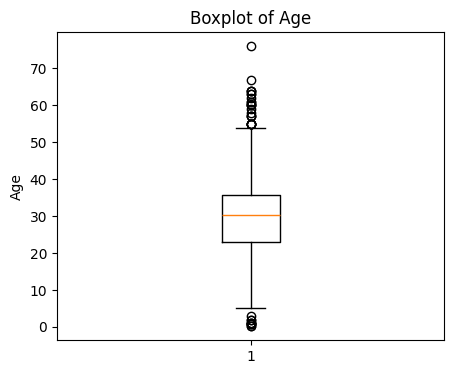

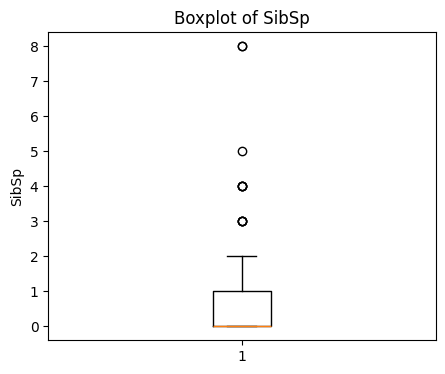

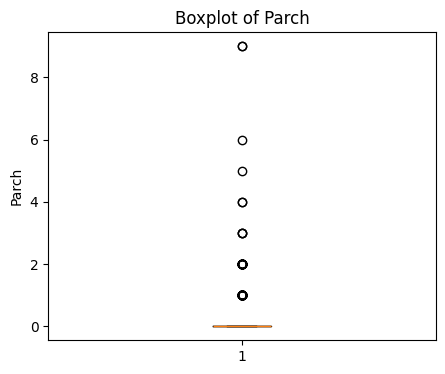

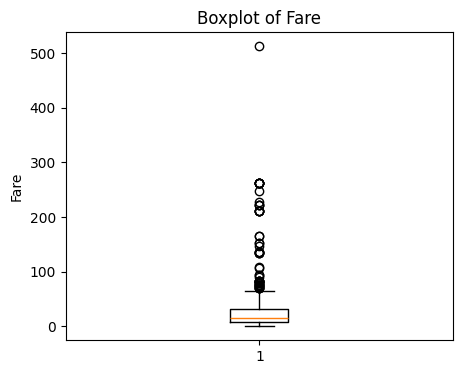


EDA Completed Successfully!


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Dataset
df = pd.read_csv("titanic.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

# 2. Data Cleaning
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Fill missing numeric values with mean
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Fill missing categorical values with mode
categorical_cols = df.select_dtypes(exclude=np.number).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# 3. Summary Statistics
print("\nSummary Statistics:")
print(df.describe())

# 4. Distribution Plots (Histograms)
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20, edgecolor='black')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

# 5. Correlation Matrix
correlation = df[numeric_cols].corr()

print("\nCorrelation Matrix:")
print(correlation)

# 6. Correlation Heatmap using Matplotlib
plt.figure(figsize=(8,6))
plt.imshow(correlation, cmap='coolwarm', interpolation='nearest')

plt.colorbar(label="Correlation")

plt.xticks(range(len(correlation.columns)),
           correlation.columns,
           rotation=45)

plt.yticks(range(len(correlation.columns)),
           correlation.columns)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# 7. Boxplots for Outlier Detection
for col in numeric_cols:
    plt.figure(figsize=(5,4))
    plt.boxplot(df[col], vert=True)
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

print("\nEDA Completed Successfully!")
